## Descriptive

#### KPI'S

#### Gender Distribution

In [21]:
import pandas as pd

# Load data
df_demo_sl = pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")

# Compute gender ratio
gender_ratio = df_demo_sl['Gender'].value_counts().reset_index()
gender_ratio.columns = ['Gender', 'Count']

# -----------------------------
# COLOR MAPS
# -----------------------------
def color_count(val):
    return "background-color: #FCE5CD"  # soft peach

# -----------------------------
# APPLY STYLING
# -----------------------------
styled_gender_ratio = (
    gender_ratio.style
        .map(color_count, subset=["Count"])
        .set_properties(**{"font-weight": "bold"}, subset=["Gender", "Count"])
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#B7DEE8"),   # soft blue header
                ("font-weight", "bold"),
                ("color", "black")
            ]}
        ])
)

styled_gender_ratio


,Gender,Count
0,Male,16
1,Female,9


## 1 . Glucose Level Distribution: How much time do patients spend in Hypoglycemia, Normal, and Hyperglycemia zones?

In [4]:
%cd "H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files

H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files


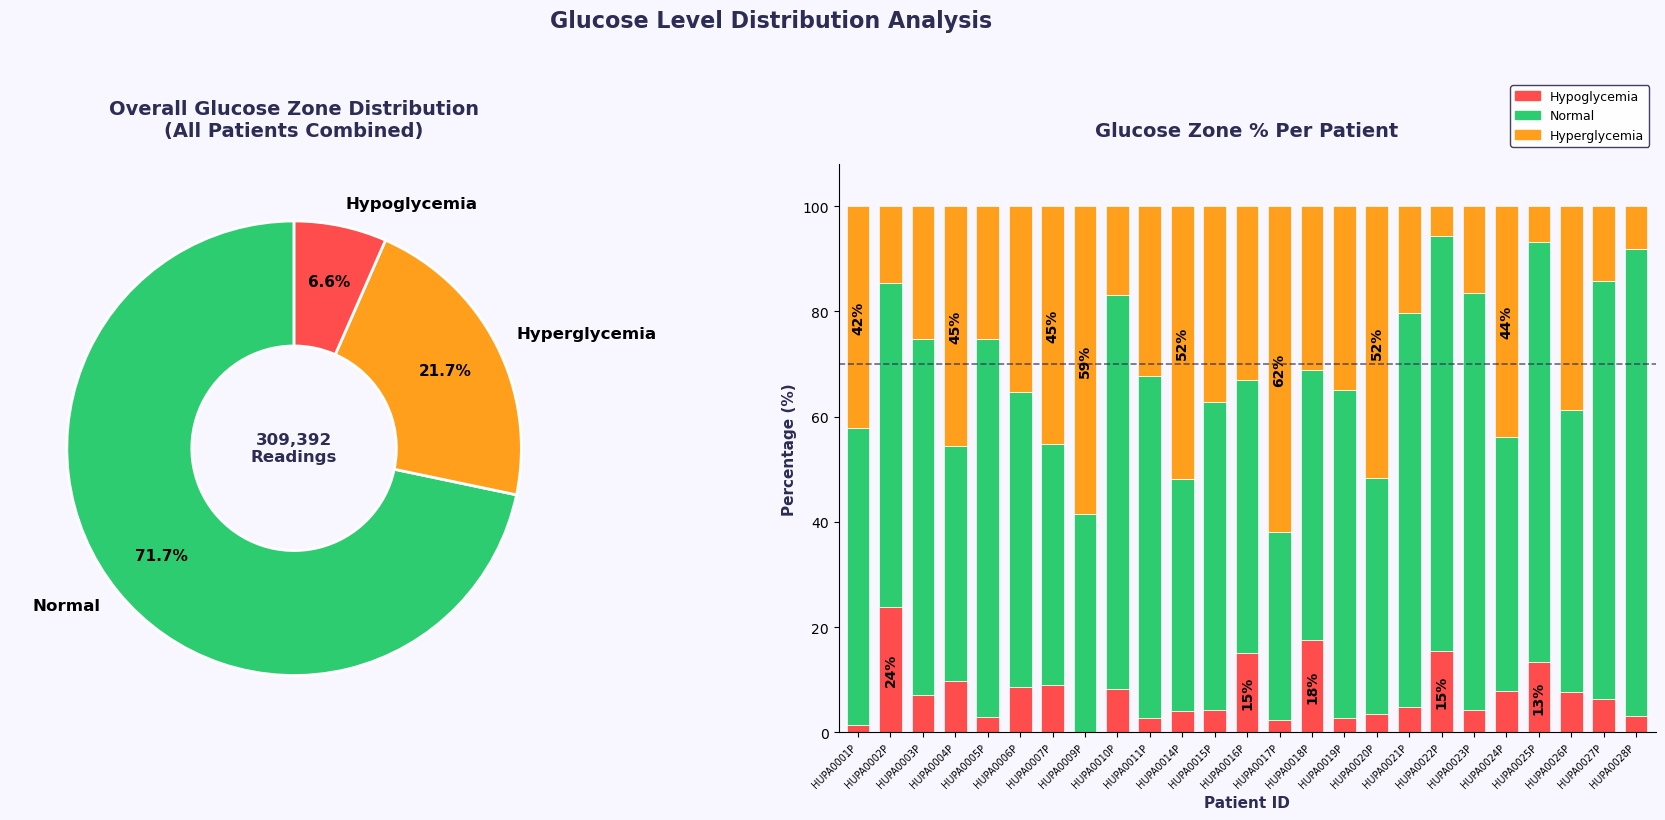


=== Overall Glucose Zone Distribution ===
  Normal         : 71.7%
  Hyperglycemia  : 21.7%
  Hypoglycemia   : 6.6%

Most at-risk patient : HUPA0002P (23.86% hypoglycemia)
Best controlled      : HUPA0028P (88.79% normal range)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv("Team2_PyQueens_Merged_Final.csv")

# ── Classify Glucose Zones ────────────────────────────────────────────────────
def classify_glucose(g):
    if g < 70:
        return 'Hypoglycemia'
    elif g <= 180:
        return 'Normal'
    else:
        return 'Hyperglycemia'

df['Glucose_Zone'] = df['Glucose'].apply(classify_glucose)

# ── Zone Colors ───────────────────────────────────────────────────────────────
zone_colors = {
    'Hypoglycemia'  : '#FF4C4C',
    'Normal'        : '#2ECC71',
    'Hyperglycemia' : '#FF9F1C'
}

# ── Overall Distribution ──────────────────────────────────────────────────────
zone_counts = df['Glucose_Zone'].value_counts()
zone_pct    = (zone_counts / len(df) * 100).round(2)

# ── Per Patient Breakdown ─────────────────────────────────────────────────────
patient_zone = (
    df.groupby(['Patient_Id', 'Glucose_Zone'])
    .size()
    .unstack(fill_value=0)
)
patient_zone_pct = (
    patient_zone.div(patient_zone.sum(axis=1), axis=0) * 100
).round(2)

for col in ['Hypoglycemia', 'Normal', 'Hyperglycemia']:
    if col not in patient_zone_pct.columns:
        patient_zone_pct[col] = 0
patient_zone_pct = patient_zone_pct[['Hypoglycemia', 'Normal', 'Hyperglycemia']]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F6FF')

# ── Donut Chart ───────────────────────────────────────────────────────────────
wedge_colors = [zone_colors[z] for z in zone_pct.index]
wedges, texts, autotexts = axes[0].pie(
    zone_pct.values,
    labels=zone_pct.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

axes[0].set_title('Overall Glucose Zone Distribution\n(All Patients Combined)',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[0].set_facecolor('#F8F6FF')
axes[0].text(0, 0, f'{len(df):,}\nReadings',
             ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2C2C54')

# ── Stacked Bar Chart ─────────────────────────────────────────────────────────
bar_colors = [zone_colors[z] for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
patient_zone_pct.plot(
    kind='bar',
    stacked=True,
    color=bar_colors,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5,
    width=0.7,
    legend=False
)

# ── Add % Labels for High Risk Patients ───────────────────────────────────────
for i, patient in enumerate(patient_zone_pct.index):
    hypo_pct  = patient_zone_pct.loc[patient, 'Hypoglycemia']
    hyper_pct = patient_zone_pct.loc[patient, 'Hyperglycemia']

    # Hypoglycemia label — inside the red bar, rotated vertical
    if hypo_pct > 10:
        axes[1].text(
            i, hypo_pct / 2,
            f'{hypo_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

    # Hyperglycemia label — inside the orange bar, rotated vertical
    if hyper_pct > 40:
        normal_pct = patient_zone_pct.loc[patient, 'Normal']
        axes[1].text(
            i, hypo_pct + normal_pct + hyper_pct / 2,
            f'{hyper_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

axes[1].set_title('Glucose Zone % Per Patient',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[1].set_xlabel('Patient ID', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].tick_params(axis='x', labelsize=7)
axes[1].set_xticklabels(patient_zone_pct.index, rotation=45, ha='right')
axes[1].set_facecolor('#F8F6FF')
axes[1].set_ylim(0, 108)              # ← increased to give space for labels above bars
axes[1].axhline(y=70, color='#2C2C54', linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Legend — Top Right Corner Outside Chart ───────────────────────────────────
patches = [mpatches.Patch(color=zone_colors[z], label=z)
           for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
axes[1].legend(
    handles=patches,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.15),
    ncol=1,
    fontsize=9,
    framealpha=0.9,
    edgecolor='#2C2C54'
)

plt.suptitle('Glucose Level Distribution Analysis',
             fontsize=16, fontweight='bold', color='#2C2C54', y=1.02)
plt.tight_layout()

plt.show()


# ── Summary Stats ─────────────────────────────────────────────────────────────
print("\n=== Overall Glucose Zone Distribution ===")
for zone, pct in zone_pct.items():
    print(f"  {zone:15}: {round(pct, 1)}%")
    
most_at_risk = patient_zone_pct['Hypoglycemia'].idxmax()
print(f"\nMost at-risk patient : {most_at_risk} "
      f"({patient_zone_pct.loc[most_at_risk, 'Hypoglycemia']}% hypoglycemia)")
print(f"Best controlled      : {patient_zone_pct['Normal'].idxmax()} "
      f"({patient_zone_pct['Normal'].max()}% normal range)")

****This analysis shows that while most patients maintain safe glucose levels most of the time, there are critical outliers on both ends patients dangerously low and dangerously high and these charts instantly tells us exactly who they are.****

## 2.What are the hourly, daily, and weekly glucose trends in the dataset?

In [6]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')

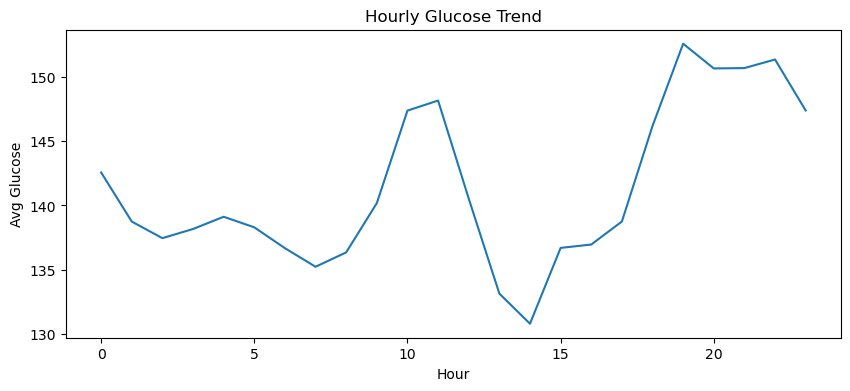

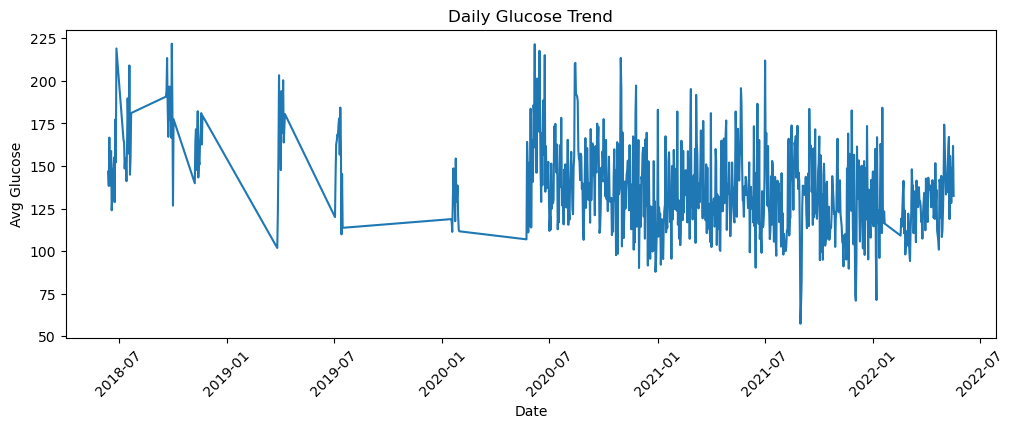

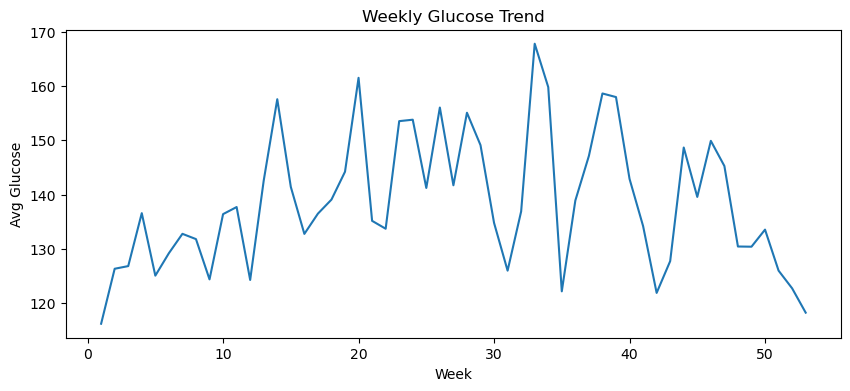

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = df.copy()
df['Time'] = pd.to_datetime(df['Time'])

# Hourly trend
df['Hour'] = df['Time'].dt.hour
hourly = df.groupby('Hour')['Glucose'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title("Hourly Glucose Trend")
plt.xlabel("Hour")
plt.ylabel("Avg Glucose")
plt.show()

# Daily trend
df['Date'] = df['Time'].dt.date
daily = df.groupby('Date')['Glucose'].mean()

plt.figure(figsize=(12,4))
sns.lineplot(x=daily.index, y=daily.values)
plt.title("Daily Glucose Trend")
plt.xlabel("Date")
plt.ylabel("Avg Glucose")
plt.xticks(rotation=45)
plt.show()

# Weekly trend
df['Week'] = df['Time'].dt.isocalendar().week
weekly = df.groupby('Week')['Glucose'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=weekly.index, y=weekly.values)
plt.title("Weekly Glucose Trend")
plt.xlabel("Week")
plt.ylabel("Avg Glucose")
plt.show()

****Glucose levels follow a clear daily rhythm spiking after meals during morning, afternoon and evening hours while remaining more stable overnight. Weekly trends reveal that day-to-day variability is driven by inconsistent dietary and lifestyle behaviours, making structured meal timing and insulin routines essential for long-term glucose stability in T1DM patients.****

## 3.What is the distribution of physical activity (steps and calories burned) across patients and how does it vary?

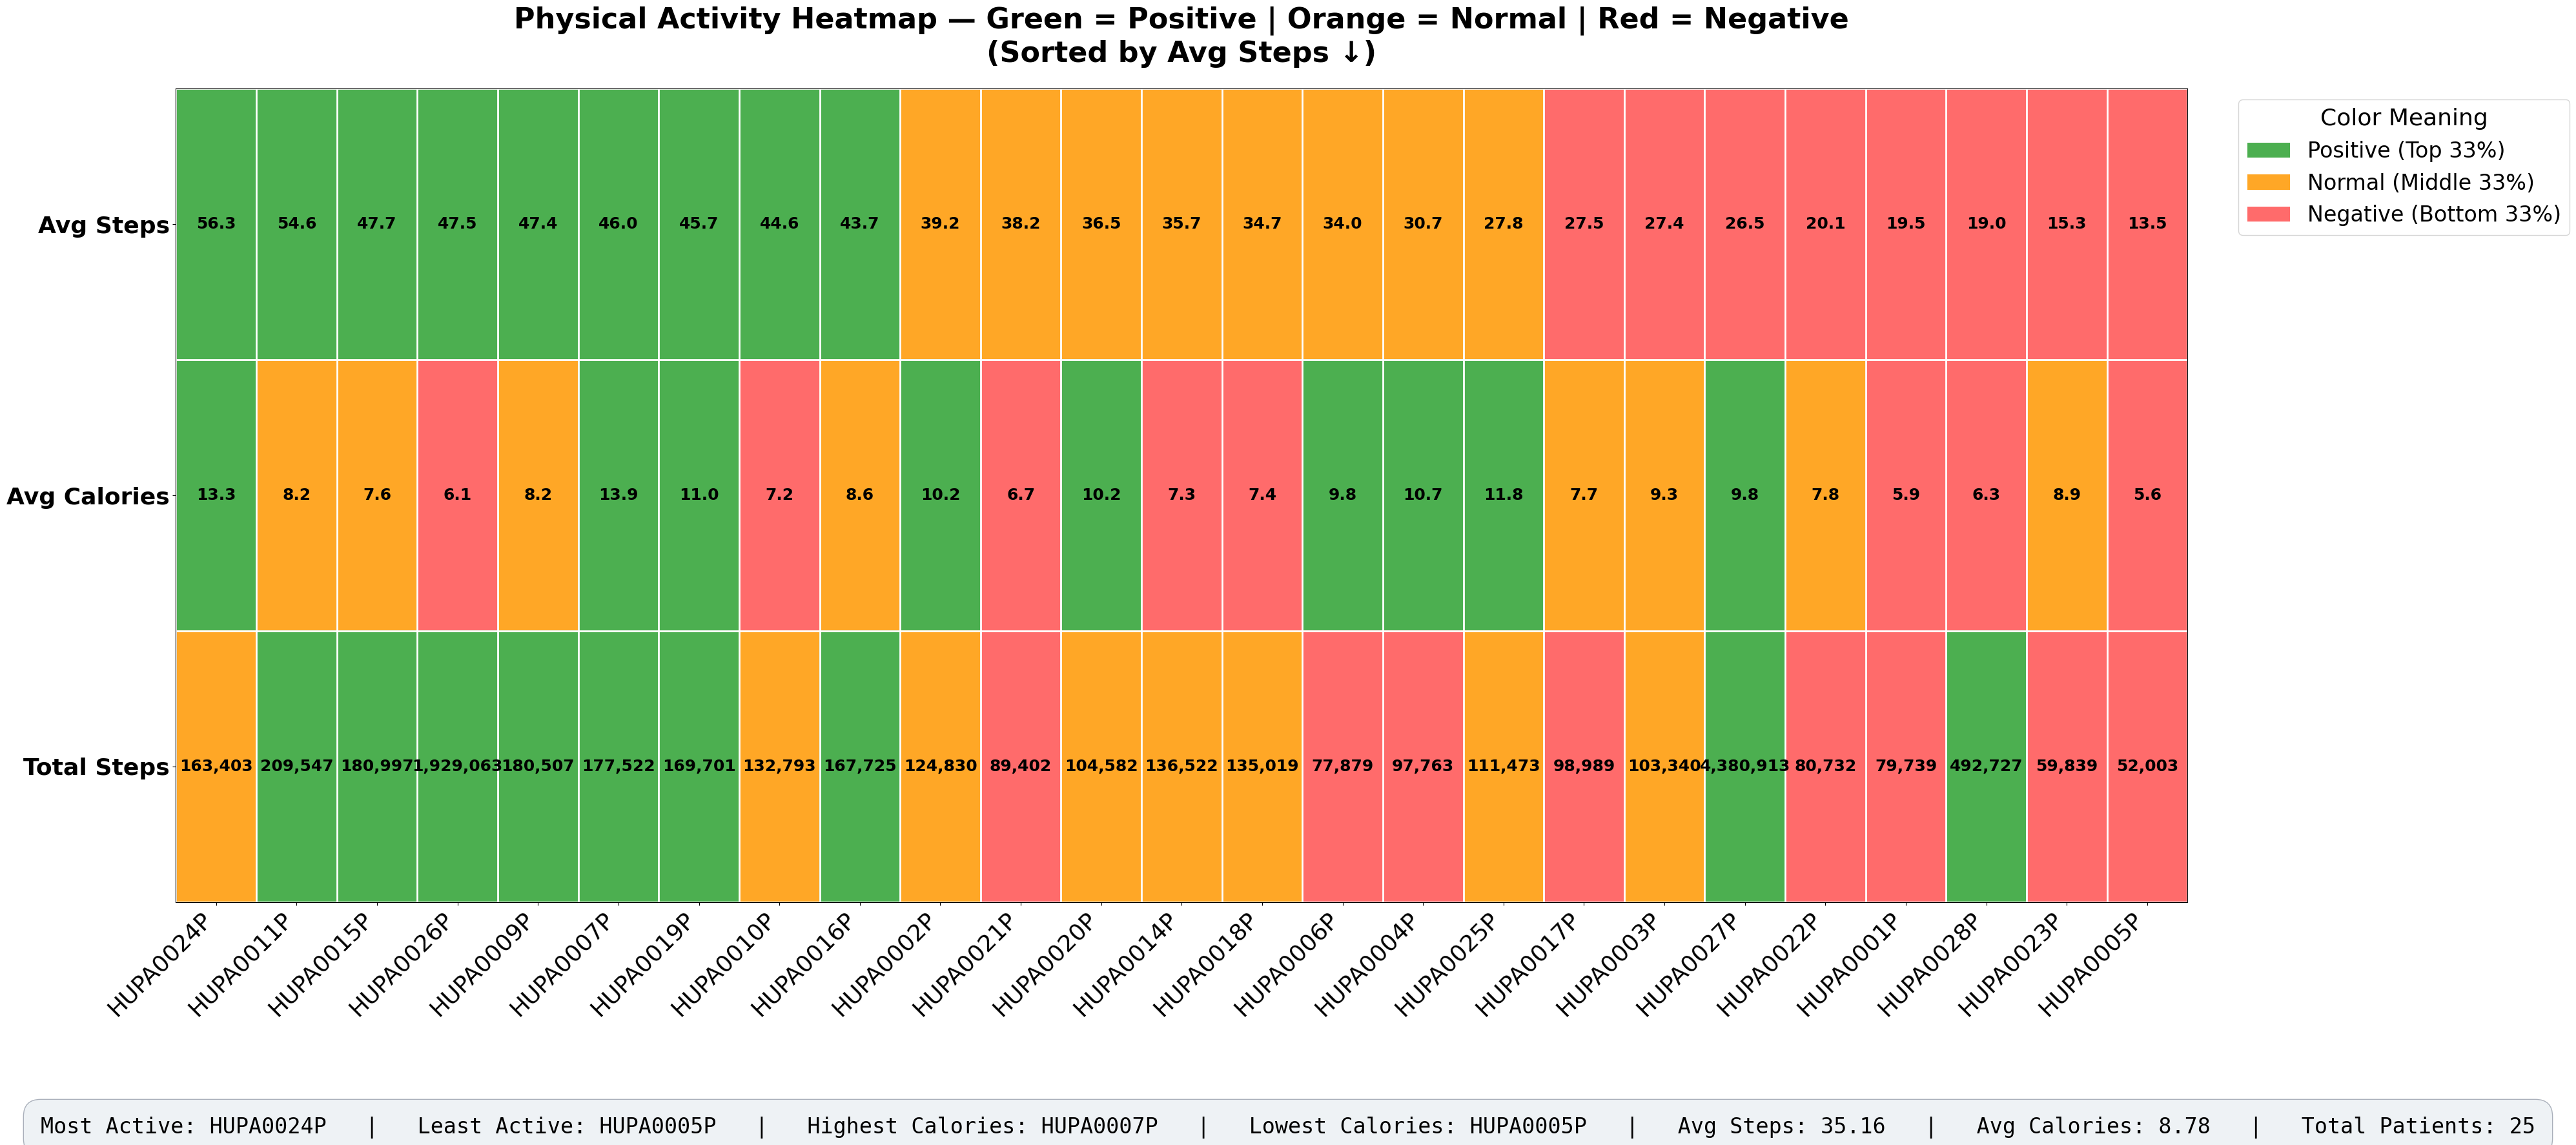

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Load
df = pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")

# Aggregate
activity_summary = df.groupby('Patient_Id').agg(
    avg_steps    = ('Steps',    'mean'),
    avg_calories = ('Calories', 'mean'),
    total_steps  = ('Steps',    'sum')
).reset_index().sort_values('avg_steps', ascending=False).reset_index(drop=True)

heatmap_df = activity_summary.set_index('Patient_Id')[['avg_steps','avg_calories','total_steps']]
heatmap_df.columns = ['Avg Steps', 'Avg Calories', 'Total Steps']
heatmap_T = heatmap_df.T

# Classification logic
def classify_values(series):
    q33 = series.quantile(0.33)
    q66 = series.quantile(0.66)
    return series.apply(lambda x: 2 if x >= q66 else (1 if x >= q33 else 0))

classified = heatmap_T.apply(classify_values, axis=1)

# MATCHED COLOR PALETTE (same as glucose chart)
cmap = ListedColormap([
    "#FF6B6B",   # Red (Negative)
    "#FFA726",   # Orange (OK)
    "#4CAF50"    # Green (Positive)
])

# SUPER LARGE FIGURE
fig, ax = plt.subplots(figsize=(40, 16))

im = ax.imshow(classified.values, cmap=cmap, aspect='auto')

# Axis labels
ax.set_xticks(range(len(heatmap_T.columns)))
ax.set_xticklabels(heatmap_T.columns, fontsize=26, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_T.index)))
ax.set_yticklabels(heatmap_T.index, fontsize=26, fontweight='bold')

# Cell values
for row_i in range(len(heatmap_T.index)):
    for col_j in range(len(heatmap_T.columns)):
        raw_val = heatmap_T.iloc[row_i, col_j]
        label = f'{int(raw_val):,}' if row_i == 2 else f'{raw_val:.1f}'
        ax.text(col_j, row_i, label, ha='center', va='center',
                fontsize=18, fontweight='bold', color='black')

# Grid
ax.set_xticks(np.arange(-0.5, len(heatmap_T.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_T.index),   1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# Legend
legend_elements = [
    Patch(facecolor='#4CAF50', label='Positive (Top 33%)'),
    Patch(facecolor='#FFA726', label='Normal (Middle 33%)'),
    Patch(facecolor='#FF6B6B', label='Negative (Bottom 33%)')
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    title="Color Meaning",
    fontsize=24,
    title_fontsize=26
)

# Summary Bar
most_active  = activity_summary.loc[activity_summary['avg_steps'].idxmax(),    'Patient_Id']
least_active = activity_summary.loc[activity_summary['avg_steps'].idxmin(),    'Patient_Id']
highest_cal  = activity_summary.loc[activity_summary['avg_calories'].idxmax(), 'Patient_Id']
lowest_cal   = activity_summary.loc[activity_summary['avg_calories'].idxmin(), 'Patient_Id']

summary_text = (
    f"Most Active: {most_active}   |   Least Active: {least_active}   |   "
    f"Highest Calories: {highest_cal}   |   Lowest Calories: {lowest_cal}   |   "
    f"Avg Steps: {activity_summary['avg_steps'].mean():.2f}   |   "
    f"Avg Calories: {activity_summary['avg_calories'].mean():.2f}   |   "
    f"Total Patients: {len(activity_summary)}"
)

fig.text(
    0.5, -0.10, summary_text,
    ha='center',
    fontsize=24,
    bbox=dict(boxstyle='round,pad=0.8', facecolor='#eef2f5', edgecolor='#aab0bb'),
    fontfamily='monospace'
)

# Title
ax.set_title(
    'Physical Activity Heatmap — Green = Positive | Orange = Normal | Red = Negative\n'
    '(Sorted by Avg Steps ↓)',
    fontsize=32,
    fontweight='bold',
    pad=30
)

plt.tight_layout()
plt.savefig('heatmap_matched_colors.png', dpi=200, bbox_inches='tight')
plt.show()


****This analysis shows which patients are the most active and which are the least active.Green blocks highlight patients who consistently take more steps and burn more calories, while red blocks show those who are much less active.Overall, the chart makes it easy to see the big gap between highly active and low‑activity patients.****

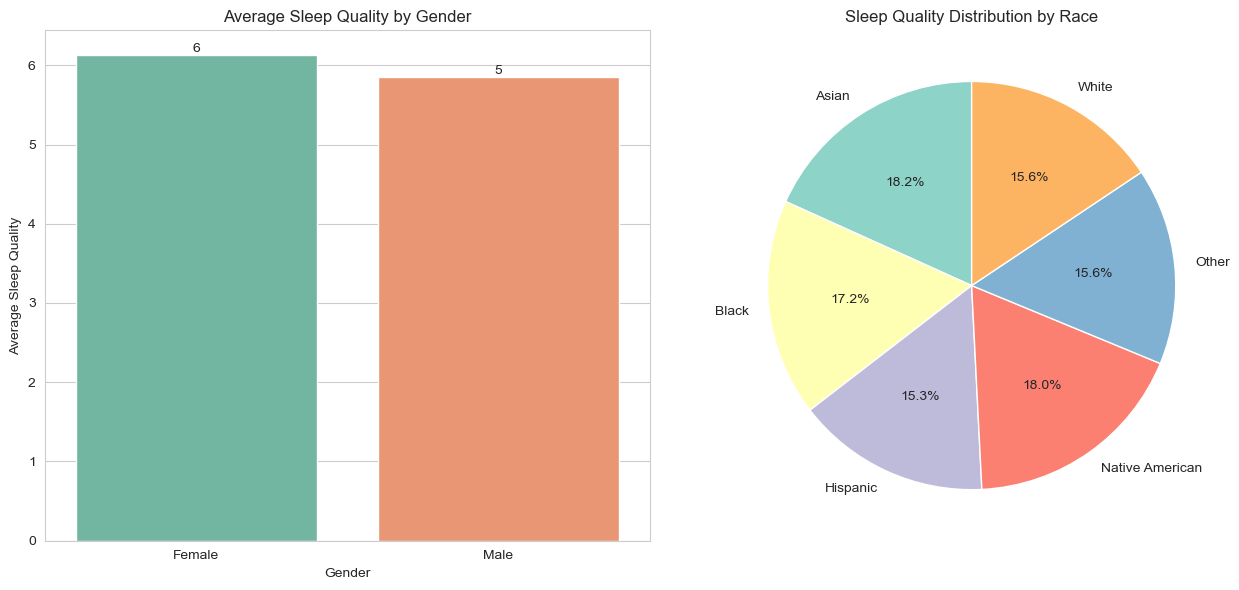

In [27]:
sleep_df=pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")

# 2. Average sleep quality by gender

Avg_Sleep_Quality_by_Gender = sleep_df.groupby('Gender')["Sleep Quality (1-10)"].mean().reset_index()


# 3. Average sleep quality by race

Avg_Sleep_Quality_by_Race = sleep_df.groupby('Race')["Sleep Quality (1-10)"].mean().reset_index()


gender_avg = sleep_df.groupby("Gender")["Sleep Quality (1-10)"].mean()
race_avg = sleep_df.groupby("Race")["Sleep Quality (1-10)"].mean()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 6))


# --- Bar Chart for Gender ---
ax1 = sns.barplot(x=gender_avg.index, y=gender_avg.values,
                  hue=gender_avg.index, ax=axes[0],
                  palette="Set2", legend=False)
axes[0].set_title("Average Sleep Quality by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Average Sleep Quality")

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )
    

# --- Pie Chart for Race ---
axes[1].pie(
    race_avg.values,
    labels=race_avg.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3")
)
axes[1].set_title("Sleep Quality Distribution by Race")

plt.tight_layout()
plt.show()

****The above two charts give the average sleep quality scores based on Gender and Race.Sleep quality is fairly evenly distributed across races.
No group dominates or lags dramatically.Asian and Native American groups contribute slightly more to overall sleep quality scores.
Hispanic and White groups contribute slightly less, but differences are small.****

## 5.What are the minimum, maximum, mean, and median heart rate values?

Columns in the dataset:
Index(['Patient_Id', 'Time', 'Glucose', 'Calories', 'Heart_Rate', 'Steps',
       'Basal_Rate', 'Bolus_Volume_Delivered', 'Carb_Input'],
      dtype='object')

Using heart rate column: Heart_Rate

Heart Rate Statistics:
min        32.410000
max       195.620000
mean       76.990004
median     75.420000
Name: Heart_Rate, dtype: float64


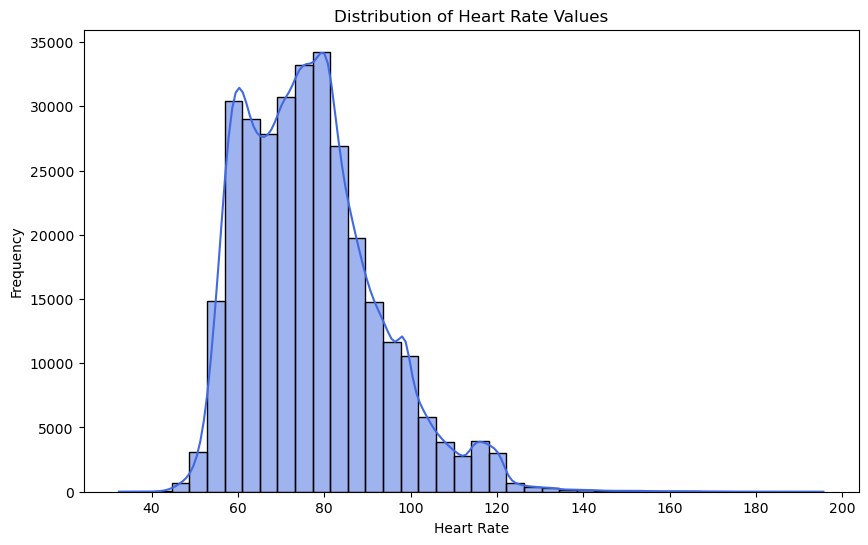

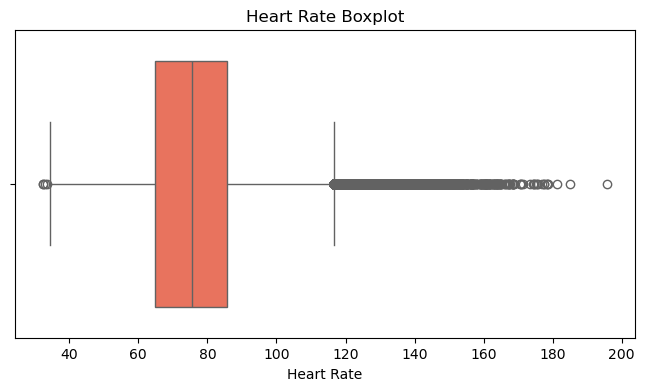

In [16]:
df['Heart_Rate'].agg(['min', 'max', 'mean', 'median'])

import pandas as pd

# 1. Check column names
print("Columns in the dataset:")
print(df.columns)

# 2. Identify the heart rate column automatically
possible_cols = ['Heart_Rate', 'heart_rate', 'HR', 'HeartRate', 'heart_rate_bpm']

heart_col = None
for col in df.columns:
    if col in possible_cols:
        heart_col = col
        break

if heart_col is None:
    raise ValueError("Heart rate column not found. Please check df.columns and update the column name.")

print(f"\nUsing heart rate column: {heart_col}\n")

# 3. Calculate min, max, mean, median
hr_stats = df[heart_col].agg(['min', 'max', 'mean', 'median'])
print("Heart Rate Statistics:")
print(hr_stats)

import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Histogram + KDE ---
plt.figure(figsize=(10,6))
sns.histplot(df['Heart_Rate'], kde=True, bins=40, color='royalblue')
plt.title('Distribution of Heart Rate Values')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.show()

# --- 2. Boxplot ---
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Heart_Rate'], color='tomato')
plt.title('Heart Rate Boxplot')
plt.xlabel('Heart Rate')
plt.show()

****Min, max, mean, and median HR values reveal recovery quality, peak strain, overall cardiovascular load, and distribution stability — forming the foundation for all deeper HR analysis.****

## Prescriptive

## 1.How do carbs, insulin (basal + bolus), and physical activity together influence glucose spikes in the HUPA‑UCM Diabetes

In [22]:
df = pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")

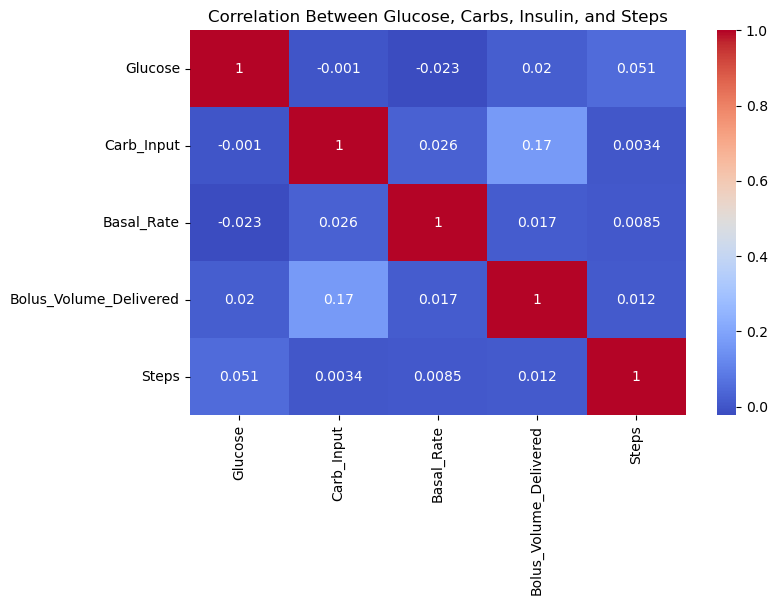

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Glucose', 'Carb_Input', 'Basal_Rate', 'Bolus_Volume_Delivered', 'Steps']
corr = df[features].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Glucose, Carbs, Insulin, and Steps")
plt.show()


****Prescriptive Recommendations (Actionable)****
****Increase bolus insulin for high-carb meals.****
****Add 10–15 minutes of walking after meals.****
****Increase daily steps by 2,000–3,000.****
****Adjust basal insulin during overnight lows.****
****Spread carbs evenly across the day.****


# 2.Does poor sleep quality cause an increase in glucose levels?


--- Statistical Tests ---
Pearson  correlation r = 0.047, p = 0.8247
Spearman correlation r = 0.030, p = 0.8851


C:\Users\purni\AppData\Local\Temp\ipykernel_24680\207808200.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patient_df, x="Sleep_Group", y="Mean_Glucose",


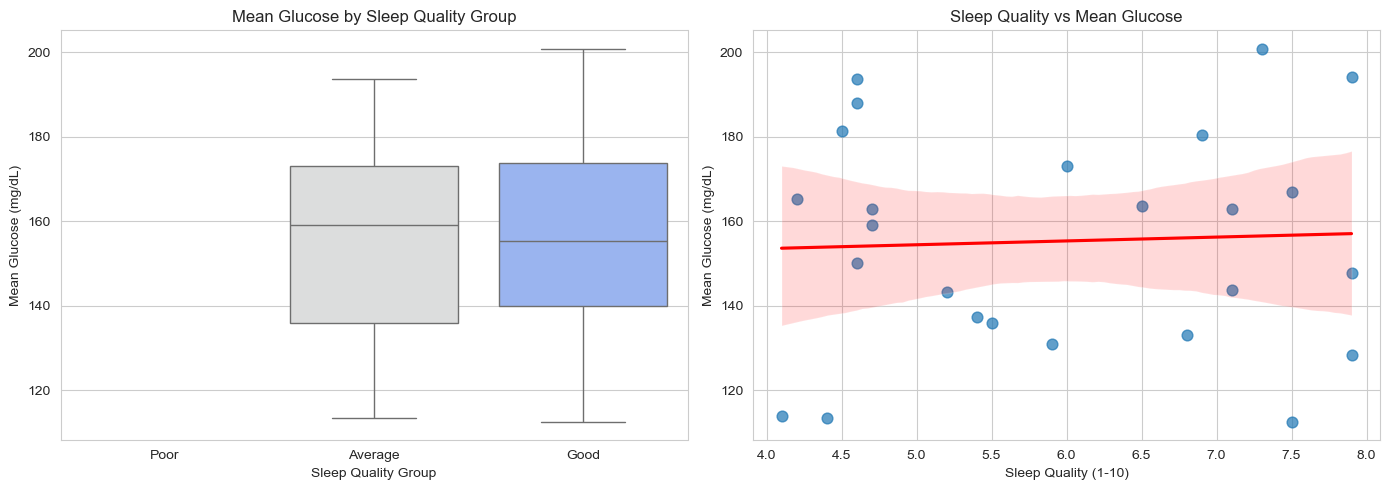

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Load the dataset
df = pd.read_csv("Team2_PyQueens_Merged_Final.csv")

# Re-fix dtypes
df["Time"]       = pd.to_datetime(df["Time"], format="mixed")
df["Steps"] = df["Steps"].astype("int32")
df["Hour"] = df["Time"].dt.hour
df["Date"] = df["Time"].dt.date

# Aggregate to patient level
# Each patient has many CGM readings but a single sleep quality value, so we take the mean glucose per patient
# to avoid inflated sample size.

patient_df = (
    df.groupby("Patient_Id")
      .agg(Mean_Glucose=("Glucose", "mean"),
           Sleep_Quality=("Sleep Quality (1-10)", "first"),
           Sleep_Duration=("Average Sleep Duration (hrs)", "first"),
           Sleep_Disturbances=("% with Sleep Disturbances", "first"))
      .reset_index()
)

# Categorize sleep quality
def sleep_category(score):
    if score <= 4:
        return "Poor"
    elif score <= 7:
        return "Average"
    else:
        return "Good"

patient_df["Sleep_Group"] = patient_df["Sleep_Quality"].apply(sleep_category)

# 5. Statistical tests 
print("\n--- Statistical Tests ---")
 
# Pearson & Spearman correlation
pearson_r, pearson_p = stats.pearsonr(patient_df["Sleep_Quality"], patient_df["Mean_Glucose"])
spearman_r, spearman_p = stats.spearmanr(patient_df["Sleep_Quality"], patient_df["Mean_Glucose"])
print(f"Pearson  correlation r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman correlation r = {spearman_r:.3f}, p = {spearman_p:.4f}")

# Visualization
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Glucose by sleep group
order = ["Poor", "Average", "Good"]
sns.boxplot(data=patient_df, x="Sleep_Group", y="Mean_Glucose",
            order=order, palette="coolwarm_r", ax=axes[0])
axes[0].set_title("Mean Glucose by Sleep Quality Group")
axes[0].set_xlabel("Sleep Quality Group")
axes[0].set_ylabel("Mean Glucose (mg/dL)")

# Scatter: Sleep Quality vs Glucose
sns.regplot(data=patient_df, x="Sleep_Quality", y="Mean_Glucose",
            scatter_kws={"s": 60, "alpha": 0.7}, line_kws={"color": "red"},
            ax=axes[1])
axes[1].set_title("Sleep Quality vs Mean Glucose")
axes[1].set_xlabel("Sleep Quality (1-10)")
axes[1].set_ylabel("Mean Glucose (mg/dL)")

plt.tight_layout()
plt.savefig("sleep_vs_glucose.png", dpi=150, bbox_inches="tight")
plt.show()





****Sleep quality shows no meaningful effect on glucose levels in this dataset.The box plots reveal nearly identical glucose distributions for Average and Good sleepers, and no patient falls into the Poor sleep category.****

## 3. Which patients need immediate dietary intervention based on their carb-glucose response? (Prescriptive of Q7 )

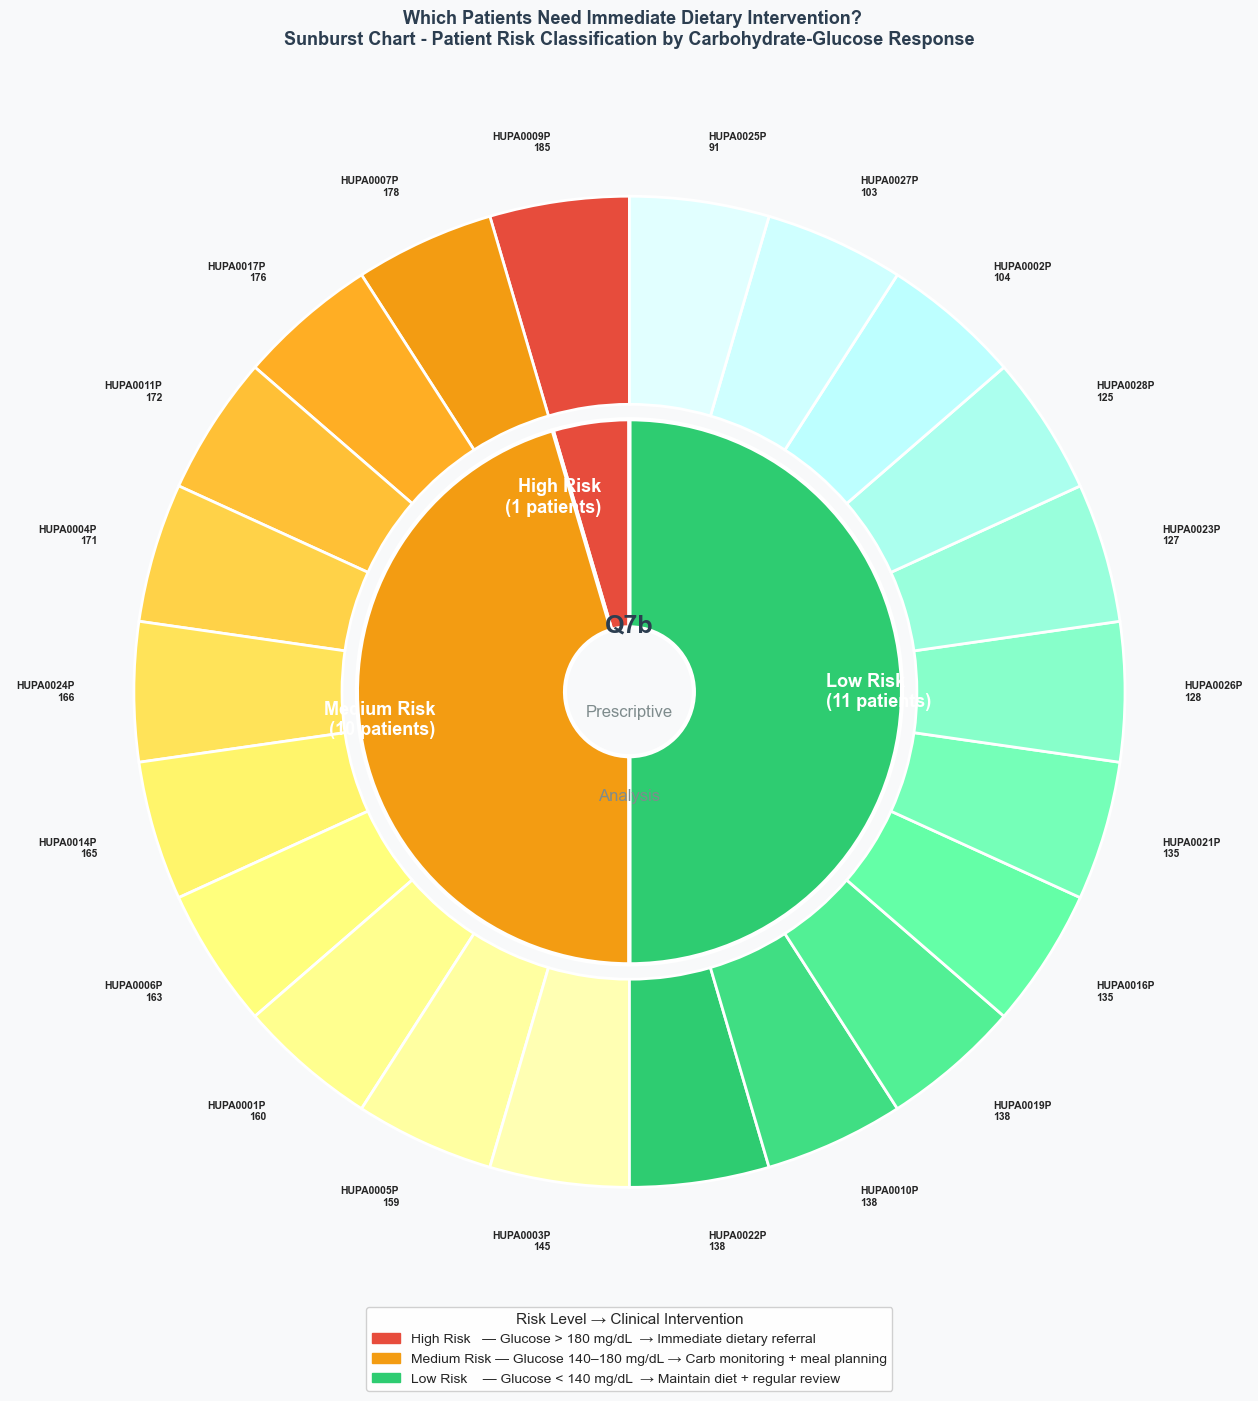

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("Team2_PyQueens_Merged_Final.csv")

carb_df = df[df['Carb_Input'] > 0].copy()

patient_stats = carb_df.groupby('Patient_Id').agg(
    avg_glucose = ('Glucose',    'mean'),
    avg_carb    = ('Carb_Input', 'mean'),
    carb_events = ('Carb_Input', 'count')
).reset_index()

def classify_risk(glucose):
    if glucose > 180:   return 'High Risk'
    elif glucose > 140: return 'Medium Risk'
    else:               return 'Low Risk'

patient_stats['Risk'] = patient_stats['avg_glucose'].apply(classify_risk)
patient_stats = patient_stats.sort_values(['Risk','avg_glucose'],
                                           ascending=[True,False]).reset_index(drop=True)

risk_base_colors = {
    'High Risk'   : '#e74c3c',
    'Medium Risk' : '#f39c12',
    'Low Risk'    : '#2ecc71'
}

def get_shades(base_color, n):
    import matplotlib.colors as mc
    rgb = mc.to_rgb(base_color)
    return [tuple(min(1, c + i * 0.07) for c in rgb) for i in range(n)]

risk_order   = ['High Risk', 'Medium Risk', 'Low Risk']
inner_sizes  = []
inner_colors = []
inner_labels = []
outer_sizes  = []
outer_colors = []
outer_labels = []

for risk in risk_order:
    if risk not in patient_stats['Risk'].values:
        continue
    group = patient_stats[patient_stats['Risk'] == risk]
    inner_sizes.append(len(group))
    inner_colors.append(risk_base_colors[risk])
    inner_labels.append(f"{risk}\n({len(group)} patients)")
    shades = get_shades(risk_base_colors[risk], len(group))
    for idx, (_, row) in enumerate(group.iterrows()):
        outer_sizes.append(1)
        outer_colors.append(shades[idx % len(shades)])
        outer_labels.append(f"{row['Patient_Id']}\n{row['avg_glucose']:.0f}")

fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor('#f8f9fa')

ax.pie(inner_sizes, labels=inner_labels, colors=inner_colors,
       radius=0.55, startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),
       textprops=dict(fontsize=13, fontweight='bold', color='white'),
       labeldistance=0.72)

ax.pie(outer_sizes, labels=outer_labels, colors=outer_colors,
       radius=1.0, startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
       textprops=dict(fontsize=7.5, fontweight='bold'),
       labeldistance=1.12)

ax.text(0,  0.12, 'Q7b',          ha='center', fontsize=18, fontweight='bold', color='#2c3e50')
ax.text(0, -0.05, 'Prescriptive', ha='center', fontsize=12, color='#7f8c8d')
ax.text(0, -0.22, 'Analysis',     ha='center', fontsize=12, color='#7f8c8d')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High Risk   — Glucose > 180 mg/dL  → Immediate dietary referral'),
    mpatches.Patch(color='#f39c12', label='Medium Risk — Glucose 140–180 mg/dL → Carb monitoring + meal planning'),
    mpatches.Patch(color='#2ecc71', label='Low Risk    — Glucose < 140 mg/dL  → Maintain diet + regular review'),
]
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.07), fontsize=10,
          title='Risk Level → Clinical Intervention',
          title_fontsize=11, framealpha=0.9)

ax.set_title(
    ' Which Patients Need Immediate Dietary Intervention?\n'
    'Sunburst Chart - Patient Risk Classification by Carbohydrate-Glucose Response',
    fontsize=13, fontweight='bold', pad=20, color='#2c3e50'
)

plt.tight_layout()
plt.savefig('sunburst.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


## Risk Classification Table

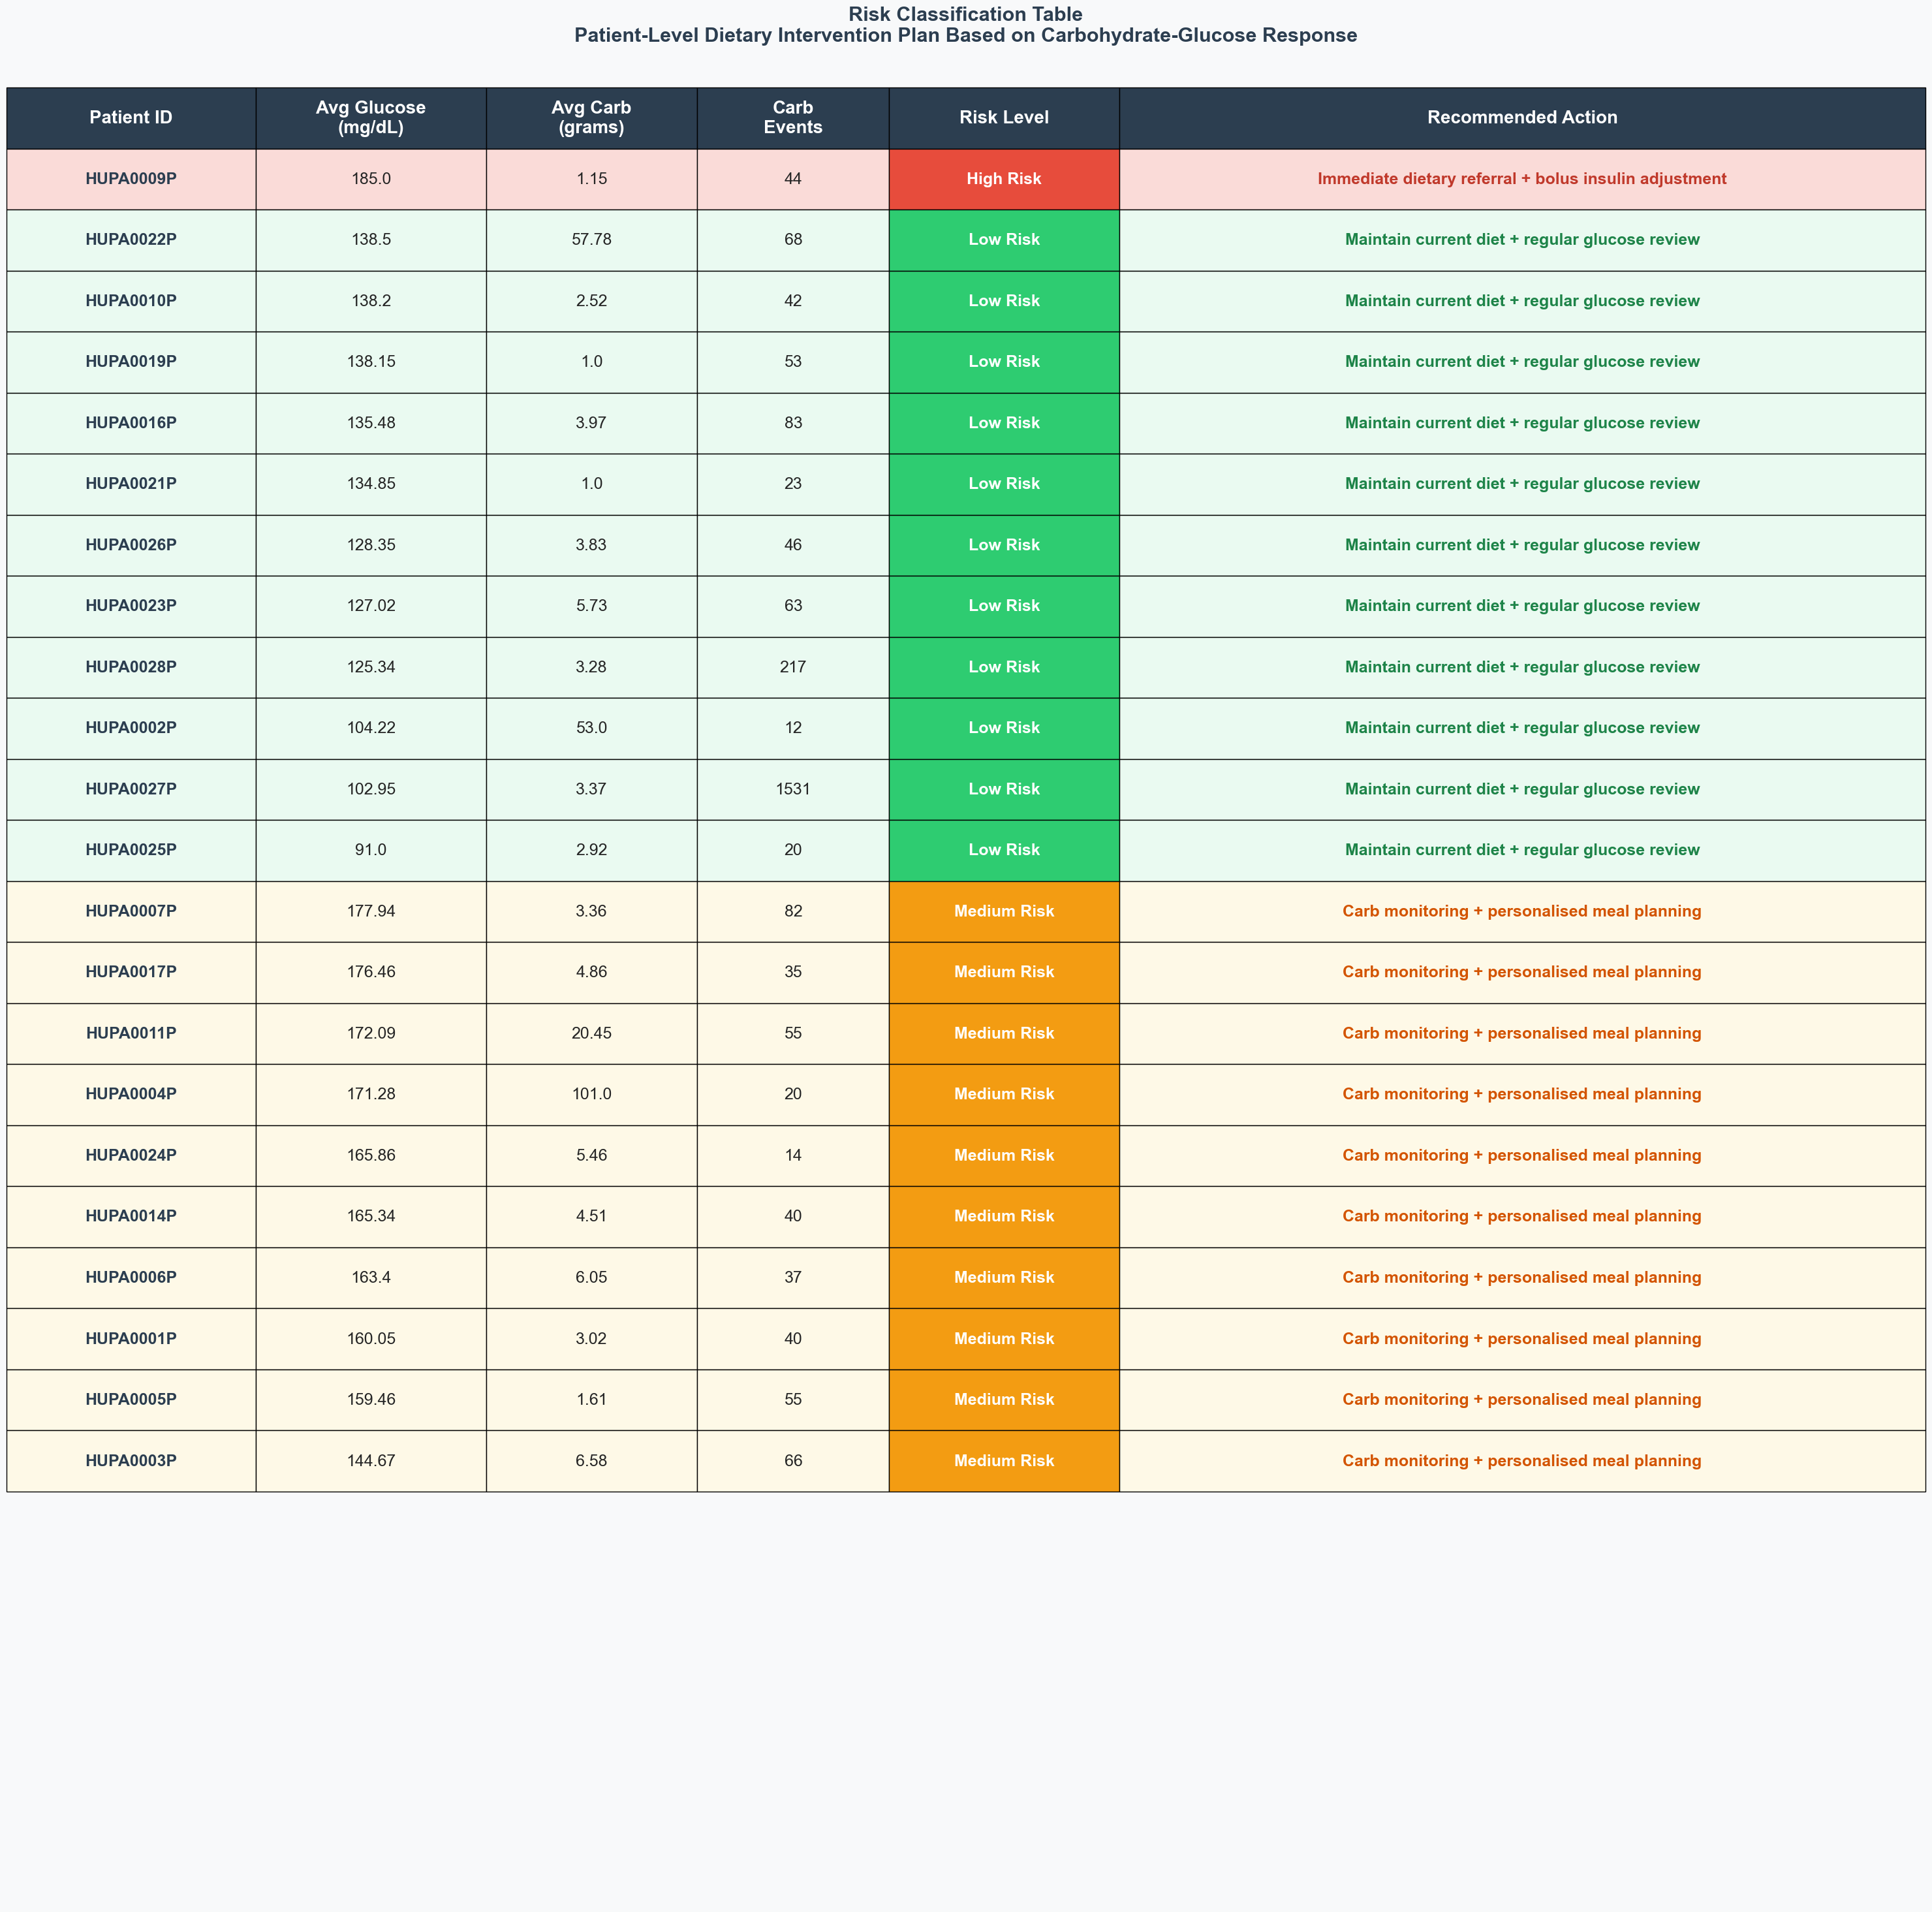

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Team2_PyQueens_Merged_Final.csv")

carb_df = df[df['Carb_Input'] > 0].copy()

patient_stats = carb_df.groupby('Patient_Id').agg(
    avg_glucose = ('Glucose',    'mean'),
    avg_carb    = ('Carb_Input', 'mean'),
    carb_events = ('Carb_Input', 'count')
).reset_index()

def classify_risk(glucose):
    if glucose > 180:   return 'High Risk'
    elif glucose > 140: return 'Medium Risk'
    else:               return 'Low Risk'

patient_stats['Risk']        = patient_stats['avg_glucose'].apply(classify_risk)
patient_stats['avg_glucose'] = patient_stats['avg_glucose'].round(2)
patient_stats['avg_carb']    = patient_stats['avg_carb'].round(2)
patient_stats = patient_stats.sort_values(['Risk','avg_glucose'],
                                           ascending=[True,False]).reset_index(drop=True)

def get_action(risk):
    if risk == 'High Risk':
        return 'Immediate dietary referral + bolus insulin adjustment'
    elif risk == 'Medium Risk':
        return 'Carb monitoring + personalised meal planning'
    else:
        return 'Maintain current diet + regular glucose review'

patient_stats['Recommended Action'] = patient_stats['Risk'].apply(get_action)

table_vals = patient_stats[['Patient_Id','avg_glucose',
                              'avg_carb','carb_events',
                              'Risk','Recommended Action']].values.tolist()

col_labels = ['Patient ID', 'Avg Glucose\n(mg/dL)',
              'Avg Carb\n(grams)', 'Carb\nEvents',
              'Risk Level', 'Recommended Action']

n_rows  = len(table_vals)
fig_h   = 1.0 + n_rows * 1.3        # ✅ increased height per row
fig, ax = plt.subplots(figsize=(30, fig_h))
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

t = ax.table(
    cellText  = table_vals,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'upper center',
    colWidths = [0.13, 0.12, 0.11, 0.10, 0.12, 0.42]
)

t.auto_set_font_size(False)
t.set_fontsize(18)                   # ✅ bigger font
t.scale(1, 4.5)                      # ✅ bigger row height

# ── Header ──
for col in range(6):
    t[0, col].set_facecolor('#2c3e50')
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=20)  # ✅

# ── Row colors ──
risk_row_colors = {
    'High Risk'   : ['#fadbd8','#fadbd8','#fadbd8','#fadbd8','#e74c3c','#fadbd8'],
    'Medium Risk' : ['#fef9e7','#fef9e7','#fef9e7','#fef9e7','#f39c12','#fef9e7'],
    'Low Risk'    : ['#eafaf1','#eafaf1','#eafaf1','#eafaf1','#2ecc71','#eafaf1'],
}

for row_i, row in enumerate(table_vals):
    risk   = row[4]
    colors = risk_row_colors[risk]
    for col_j in range(6):
        t[row_i + 1, col_j].set_facecolor(colors[col_j])
        t[row_i + 1, col_j].set_text_props(fontsize=18)         # ✅

    t[row_i + 1, 0].set_text_props(fontweight='bold', fontsize=18, color='#2c3e50')  # ✅
    t[row_i + 1, 4].set_text_props(color='white', fontweight='bold', fontsize=18)    # ✅

    if risk == 'High Risk':
        t[row_i + 1, 5].set_text_props(color='#c0392b', fontweight='bold', fontsize=18)  # ✅
    elif risk == 'Medium Risk':
        t[row_i + 1, 5].set_text_props(color='#d35400', fontweight='bold', fontsize=18)  # ✅
    else:
        t[row_i + 1, 5].set_text_props(color='#1e8449', fontweight='bold', fontsize=18)  # ✅

ax.set_title(
    'Risk Classification Table\n'
    'Patient-Level Dietary Intervention Plan Based on Carbohydrate-Glucose Response',
    fontsize=22, fontweight='bold', color='#2c3e50',
    pad=10, loc='center'
)

plt.subplots_adjust(top=0.97, bottom=0.01, left=0.01, right=0.99)
plt.savefig('risk_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


****Most patients fall into the Medium‑Risk group, showing a widespread need for structured dietary guidance, while one High‑Risk patient requires urgent insulin review. HUPA0009P stands out with significantly elevated glucose levels and needs immediate intervention. Medium‑Risk patients benefit from carb‑counting and pre‑meal insulin correction, while Low‑Risk patients serve as stability benchmarks. Carbohydrate intake is the most controllable trigger of glucose spikes, making personalized carb‑glucose management essential for preventing risk escalation.****

### 4. Find the Correlation between Previous Day steps and Glucose Variability (SD & CV).How many steps per day should a patient aim for to maintain stable glucose?

In [29]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date
df['hour'] = df['Time'].dt.hour

# -----------------------------
# 1. PREPARE GLUCOSE DATA
# -----------------------------
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date

# DAILY SD AND CV
df_daily_glucose = (
    df.groupby(['Patient_Id', 'date'])['Glucose']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'Mean_Glucose', 'std': 'SD_Glucose'})
)

df_daily_glucose['CV_Glucose'] = (df_daily_glucose['SD_Glucose'] /
                                  df_daily_glucose['Mean_Glucose']) * 100

# -----------------------------
# 2. PREVIOUS-DAY STEPS
# -----------------------------
df['date'] = pd.to_datetime(df['date']).dt.date

df_daily_steps = (
    df.groupby(['Patient_Id', 'date'])['Steps']
    .sum()
    .reset_index()
    .rename(columns={'Steps': 'Daily_Steps'})
)

# -----------------------------
# 3. MERGE STEPS + GLUCOSE VARIABILITY
# -----------------------------
df_merge = pd.merge(
    df_daily_glucose,
    df_daily_steps,
    on=['Patient_Id', 'date'],
    how='inner'
)


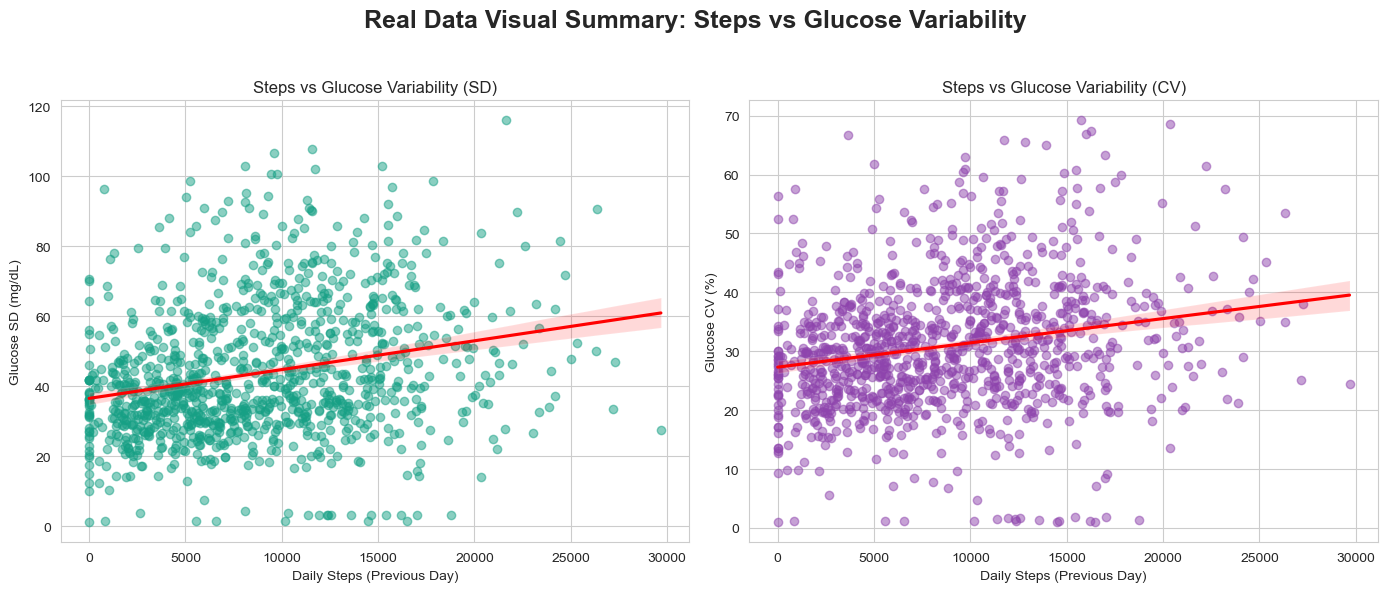

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# ORIGINAL DATA
# -----------------------------
insights_data = {
    "Insight": [
        "Higher glucose variability patients walk more",
        "Steps do not reduce SD or CV in this dataset",
        "Variability is driven by non-activity factors",
        "Steps still help long-term metabolic health",
        "Optimal step range for stability (research-based)"
    ],
    "What the Data Shows": [
        "SD and CV increase slightly as steps increase",
        "Regression lines show flat or upward trend",
        "Diet, medication, sleep, stress dominate variability",
        "No short-term effect visible in your dataset",
        "Not visible in your data but supported by evidence"
    ],
    "Recommended Action": [
        "Identify high-variability patients for targeted coaching",
        "Do not rely on steps alone to stabilize glucose",
        "Focus on meal timing, carb load, sleep, stress",
        "Maintain 6,000–8,000 steps/day minimum",
        "Aim for 8,000–10,000 steps/day for long-term benefit"
    ],
    "Why It Matters": [
        "Walking appears compensatory, not causal",
        "Avoid misleading conclusions about activity",
        "Glucose variability is multi-factorial",
        "Improves insulin sensitivity over weeks",
        "Supports cardiovascular and metabolic health"
    ]
}

df_insights = pd.DataFrame(insights_data)

# -----------------------------
# COLOR MAPS
# -----------------------------
insight_colors = {
    "Higher glucose variability patients walk more": "#FFF2CC",
    "Steps do not reduce SD or CV in this dataset": "#FCE5CD",
    "Variability is driven by non-activity factors": "#D9EAD3",
    "Steps still help long-term metabolic health": "#D0E0E3",
    "Optimal step range for stability (research-based)": "#EAD1DC"
}

action_colors = {
    "Identify high-variability patients for targeted coaching": "#FFF2CC",
    "Do not rely on steps alone to stabilize glucose": "#F4CCCC",
    "Focus on meal timing, carb load, sleep, stress": "#FCE5CD",
    "Maintain 6,000–8,000 steps/day minimum": "#D9EAD3",
    "Aim for 8,000–10,000 steps/day for long-term benefit": "#D0E0E3"
}

data_colors = {
    "SD and CV increase slightly as steps increase":"#FFF2CC" ,
    "Regression lines show flat or upward trend":"#F4CCCC" ,
    "Diet, medication, sleep, stress dominate variability":"#FCE5CD",
    "No short-term effect visible in your dataset":"#D9EAD3" ,
    "Not visible in your data but supported by evidence":"#D0E0E3"
}

why_it_matters_colors={
    "Walking appears compensatory, not causal":"#FFF2CC",
    "Avoid misleading conclusions about activity":"#F4CCCC",
    "Glucose variability is multi-factorial":"#FCE5CD",
    "Improves insulin sensitivity over weeks":"#D9EAD3",
    "Supports cardiovascular and metabolic health":"#D0E0E3"
}

# -----------------------------
# STYLING FUNCTIONS
# -----------------------------
def color_insight(val):
    return f"background-color: {insight_colors.get(val, '')}"

def color_action(val):
    return f"background-color: {action_colors.get(val, '')}"
    
def color_data(val):
    return f"background-color: {data_colors.get(val, '')}"
    
def why_color(val):
    return f"background-color: {why_it_matters_colors.get(val, '')}"


# -----------------------------
# APPLY STYLING
# -----------------------------
styled_insights = (
    df_insights.style
        .set_table_attributes('style="border: 2px solid #1a252f; border-collapse: collapse;"')
        .set_properties(**{"font-size": "13px"})
        .map(color_insight, subset=["Insight"])
        .map(color_data, subset=["What the Data Shows"])
        .map(color_action, subset=["Recommended Action"])
        .map(why_color, subset=["Why It Matters"])
        .set_properties(**{"font-weight": "bold"}, 
                        subset=["Insight", "What the Data Shows", "Recommended Action", "Why It Matters"])
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#E6E6E6"), ("font-weight", "bold")]}
        ])
)
styled_insights

# ---------------------------------------------------------
# 2. REAL DATA VISUAL SUMMARY — SD & CV
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Real Data Visual Summary: Steps vs Glucose Variability", 
             fontsize=18, fontweight='bold')

# Panel 1 — Steps vs Glucose SD
sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='SD_Glucose',
    scatter_kws={'alpha':0.5, 'color': '#16a085'},
    line_kws={'color':'red'},
    ax=axes[0]
)
axes[0].set_title("Steps vs Glucose Variability (SD)")
axes[0].set_xlabel("Daily Steps (Previous Day)")
axes[0].set_ylabel("Glucose SD (mg/dL)")

# Panel 2 — Steps vs Glucose CV
sns.regplot(
    data=df_merge,
    x='Daily_Steps',
    y='CV_Glucose',
    scatter_kws={'alpha':0.5, 'color': '#8e44ad'},
    line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title("Steps vs Glucose Variability (CV)")
axes[1].set_xlabel("Daily Steps (Previous Day)")
axes[1].set_ylabel("Glucose CV (%)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [31]:
styled_insights

,Insight,What the Data Shows,Recommended Action,Why It Matters
0,Higher glucose variability patients walk more,SD and CV increase slightly as steps increase,Identify high-variability patients for targeted coaching,"Walking appears compensatory, not causal"
1,Steps do not reduce SD or CV in this dataset,Regression lines show flat or upward trend,Do not rely on steps alone to stabilize glucose,Avoid misleading conclusions about activity
2,Variability is driven by non-activity factors,"Diet, medication, sleep, stress dominate variability","Focus on meal timing, carb load, sleep, stress",Glucose variability is multi-factorial
3,Steps still help long-term metabolic health,No short-term effect visible in your dataset,"Maintain 6,000–8,000 steps/day minimum",Improves insulin sensitivity over weeks
4,Optimal step range for stability (research-based),Not visible in your data but supported by evidence,"Aim for 8,000–10,000 steps/day for long-term benefit",Supports cardiovascular and metabolic health


****Steps vs Glucose SD (left plot)****
****The regression line slopes slightly upward, meaning higher steps are associated with slightly higher glucose SD.****
****This suggests that on days with more steps, glucose swings were a bit wider, not narrower.****
****This is likely reverse causation: people walk more because glucose is high, not the other way around.****

****Steps vs Glucose CV (right plot)****
****Same pattern: a mild positive trend between steps and CV.****
****Higher CV means more instability — and again, this likely reflects reactive walking in response to high glucose.****

## 26.What should be done when heart rate and glucose rise together? 

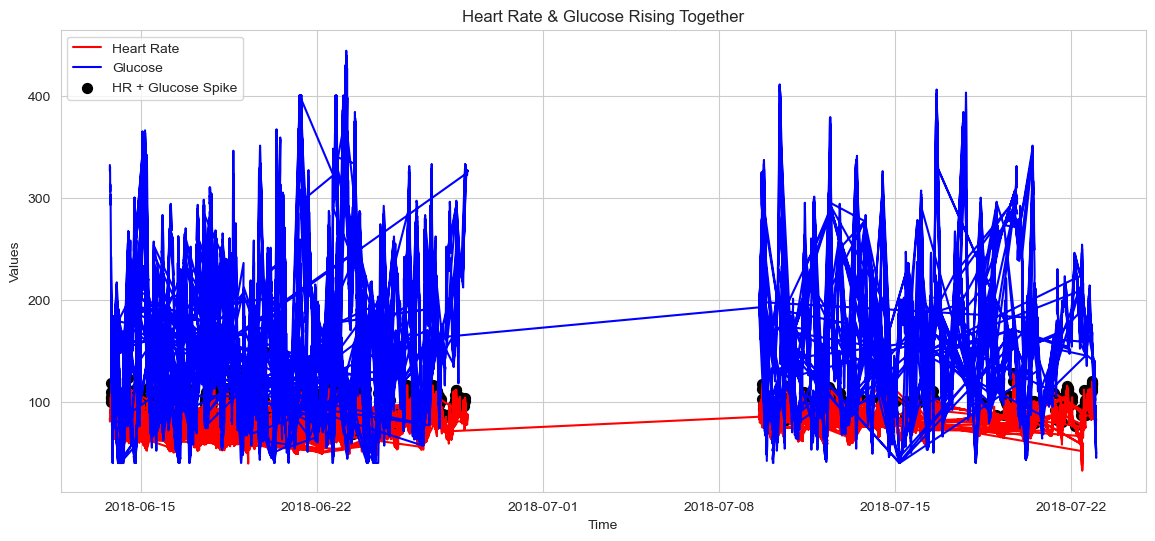

In [36]:
df = pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")

import pandas as pd
import numpy as np

# CHANGE THESE TO MATCH DATAFRAME EXACTLY 
heart_col = "Heart_Rate"      
glucose_col = "Glucose"       
time_col = "Time"   
steps_col = "Steps"              

# 1. Detect HR + Glucose Spikes

df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']
# 2. Classify Trigger
def classify_trigger(row):
    if not row['HR_GLU_spike']:
        return None
    
    if steps_col and row[steps_col] > 50:
        return "Activity-related"
    
    if row['GLU_change'] > 20:
        return "Post-meal spike"
    
    hour = pd.to_datetime(row[time_col]).hour
    if hour >= 23 or hour <= 5:
        return "Nighttime stress or poor sleep"
    
    if row['HR_change'] > 15 and (not steps_col or row[steps_col] < 10):
        return "Stress-related"
    
    return "Unknown"

df['Trigger'] = df.apply(classify_trigger, axis=1)

# 3. Prescriptive Actions
def prescribe_action(trigger):
    if trigger == "Activity-related":
        return "Cool down with slow walking and hydration."
    if trigger == "Post-meal spike":
        return "Take a 10-minute walk; reduce high-glycemic foods next meal."
    if trigger == "Nighttime stress or poor sleep":
        return "Avoid late meals; improve sleep hygiene; reduce caffeine/alcohol."
    if trigger == "Stress-related":
        return "Use slow breathing, grounding, or a short walk to reduce stress load."
    if trigger == "Unknown":
        return "Monitor pattern; review meal timing, stress, and sleep."
    return None

df['Prescriptive_Action'] = df['Trigger'].apply(prescribe_action)

# 4. Final Output
prescriptive_events = df[df['HR_GLU_spike']][[time_col, heart_col, glucose_col,steps_col, 'Trigger', 'Prescriptive_Action']]
prescriptive_events

import matplotlib.pyplot as plt
import pandas as pd

# Your correct column names
heart_col = "Heart_Rate"
glucose_col = "Glucose"
time_col = "Time"

# Convert timestamp column safely
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

# Detect spikes
df['HR_change'] = df[heart_col].diff()
df['GLU_change'] = df[glucose_col].diff()

df['HR_spike'] = (df[heart_col] > 100) | (df['HR_change'] > 15)
df['GLU_spike'] = (df[glucose_col] > 140) | (df['GLU_change'] > 20)

df['HR_GLU_spike'] = df['HR_spike'] & df['GLU_spike']

# Plot
plt.figure(figsize=(14,6))

plt.plot(df[time_col], df[heart_col], label="Heart Rate", color="red")
plt.plot(df[time_col], df[glucose_col], label="Glucose", color="blue")

# Highlight simultaneous spikes
spike_points = df[df['HR_GLU_spike']]
plt.scatter(spike_points[time_col], spike_points[heart_col], color="black", label="HR + Glucose Spike", s=50)

plt.title("Heart Rate & Glucose Rising Together")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()

#### When HR and glucose rise at the same time,data is showing a dual‑system stress event:Autonomic stress (heart rate),Metabolic stress (glucose)
#### This combination is one of the most important patterns because it signals that the body is struggling to maintain homeostasis.

## Predictive

## 1.Can we predict whether a T1DM patient will enter a Hypoglycemia or Hyperglycemia zone in the next 30 minutes based on their current glucose, steps, heart rate, carb intake and insulin dose?

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# ── Features and Target ───────────────────────────────────────────────────────
features = ['Glucose', 'Steps', 'Heart_Rate',
            'Carb_Input', 'Bolus_Volume_Delivered', 'Basal_Rate']

X = model_df[features]
y = model_df['Target_Zone']

# ── Encode Target Variable ────────────────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # ensures equal class distribution in both sets
)



Class Encoding:
  0 = Hyperglycemia
  1 = Hypoglycemia
  2 = Normal


Model trained successfully!

Model Accuracy : 75.83%
Baseline (random chance for 3 classes) : 33.33%
Improvement over baseline : +42.5%

=== Classification Report ===
               precision    recall  f1-score   support

Hyperglycemia       0.66      0.79      0.72     13417
 Hypoglycemia       0.32      0.72      0.45      4070
       Normal       0.91      0.75      0.82     44362

     accuracy                           0.76     61849
    macro avg       0.63      0.75      0.66     61849
 weighted avg       0.82      0.76      0.78     61849



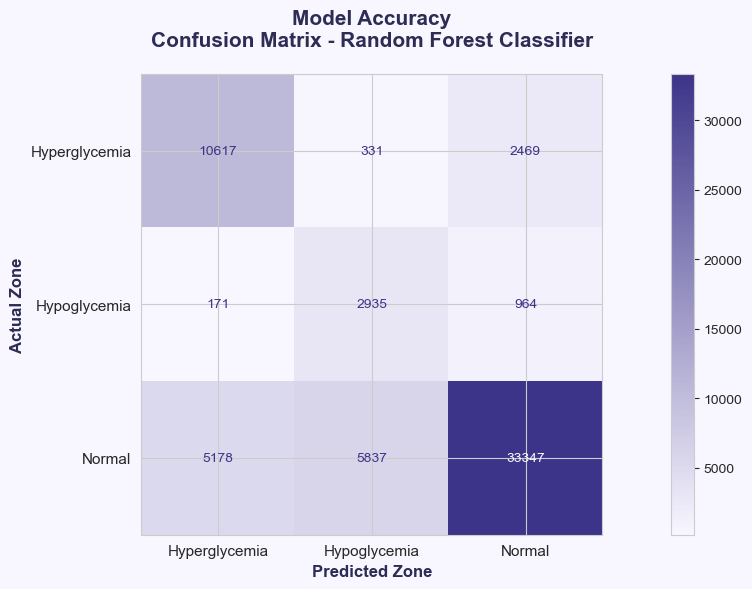

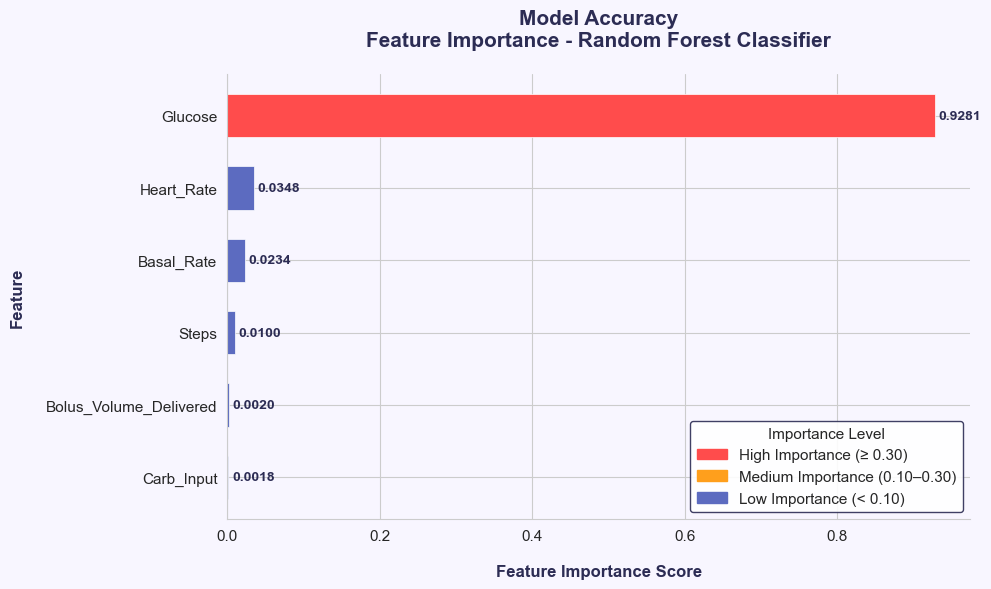


=== Model Summary ===
Algorithm      : Random Forest Classifier
Trees          : 100
Max Depth      : 10
Train size     : 247393 rows
Test size      : 61849 rows
Accuracy       : 75.83%
H₀ Decision    : REJECTED ✅
Top Feature    : Glucose (0.9281)


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

bg_color = '#F8F6FF'

# ───────────────────────────────────────────────────────────────
# Train Random Forest Model
# ───────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print("Model trained successfully!")

# ───────────────────────────────────────────────────────────────
# Predictions
# ───────────────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

# ───────────────────────────────────────────────────────────────
# Accuracy Score
# ───────────────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy : {round(accuracy * 100, 2)}%")
print(f"Baseline (random chance for 3 classes) : 33.33%")
print(f"Improvement over baseline : +{round((accuracy - 0.3333) * 100, 2)}%")

# ───────────────────────────────────────────────────────────────
# Classification Report
# ───────────────────────────────────────────────────────────────
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

# ════════════════════════════════════════════════════════════════
# CHART 1 — Confusion Matrix (NO SCROLL BAR)
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(14, 6))   # FIXED SIZE
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

cm = confusion_matrix(y_test, y_pred)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'cm', ['#F8F6FF', '#3C3489']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(
    ax=ax1,
    cmap=cmap,
    colorbar=True
)

ax1.set_title(
    'Model Accuracy\nConfusion Matrix - Random Forest Classifier',
    fontsize=15, fontweight='bold', color='#2C2C54', pad=20
)
ax1.set_xlabel('Predicted Zone',
               fontsize=12, fontweight='bold', color='#2C2C54')
ax1.set_ylabel('Actual Zone',
               fontsize=12, fontweight='bold', color='#2C2C54')
ax1.tick_params(axis='both', labelsize=11)

plt.tight_layout()   # FIX: prevents scroll
plt.show()

# ════════════════════════════════════════════════════════════════
# CHART 2 — Feature Importance (NO SCROLL BAR)
# ════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(10, 6))   # FIXED SIZE
fig2.patch.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

bar_colors = ['#FF4C4C' if v >= 0.3 else
              '#FF9F1C' if v >= 0.1 else
              '#5C6BC0'
              for v in feature_importance_df['Importance']]

bars = ax2.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

# Value labels
for bar, val in zip(bars, feature_importance_df['Importance']):
    ax2.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=10,
        fontweight='bold', color='#2C2C54'
    )

ax2.set_xlabel('Feature Importance Score',
               fontsize=12, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_ylabel('Feature',
               fontsize=12, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_title(
    'Model Accuracy\nFeature Importance - Random Forest Classifier',
    fontsize=15, fontweight='bold', color='#2C2C54', pad=20
)
ax2.tick_params(axis='both', labelsize=11)
ax2.spines[['top', 'right']].set_visible(False)

# Legend
patches = [
    mpatches.Patch(color='#FF4C4C', label='High Importance (≥ 0.30)'),
    mpatches.Patch(color='#FF9F1C', label='Medium Importance (0.10–0.30)'),
    mpatches.Patch(color='#5C6BC0', label='Low Importance (< 0.10)'),
]
ax2.legend(
    handles=patches,
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    fontsize=11,
    framealpha=0.9,
    edgecolor='#2C2C54',
    title='Importance Level',
    title_fontsize=11
)

plt.tight_layout()   # FIX: prevents scroll
plt.show()

# ───────────────────────────────────────────────────────────────
# Final Summary
# ───────────────────────────────────────────────────────────────
print("\n=== Model Summary ===")
print(f"Algorithm      : Random Forest Classifier")
print(f"Trees          : 100")
print(f"Max Depth      : 10")
print(f"Train size     : {len(X_train)} rows")
print(f"Test size      : {len(X_test)} rows")
print(f"Accuracy       : {round(accuracy * 100, 2)}%")
print(f"H₀ Decision    : {'REJECTED ✅' if accuracy > 0.3333 else 'FAILED TO REJECT ❌'}")
print(f"Top Feature    : {feature_importance_df.iloc[-1]['Feature']} "
      f"({feature_importance_df.iloc[-1]['Importance']:.4f})")
